# DualSentinel — Pipeline Notebook

Simulates:
```bash
python src/pipeline.py \
  --input "data/samples/LMD-2023 [1.75M Elements - Normal]checked.csv" \
  --dataset lmd \
  --skip-detectors \
  --threshold 0.0
```

Each cell corresponds to one pipeline step, making it easy to inspect intermediate results, re-run individual steps, and change parameters without re-running the entire pipeline.

**Requirements:** Ollama must be running (`ollama serve`) with `phi3:mini` and `llama3.2` pulled.

## Configuration
Edit these variables to change the run without touching any source files.

In [26]:
import sys, os
from pathlib import Path

# Locate the DualSentinel root regardless of where the kernel was launched from.
# The root is the first ancestor (or sibling) directory that owns src/pipeline.py.
_cwd = Path.cwd()
_candidates = [
    _cwd,                          # kernel started inside DualSentinel/
    _cwd / 'DualSentinel',         # kernel started at workspace root
    _cwd.parent,                   # kernel started inside DualSentinel/notebooks/
    _cwd.parent / 'DualSentinel',  # kernel started at Challange-3 parent
]
_root = next((p.resolve() for p in _candidates if (p / 'src' / 'pipeline.py').exists()), _cwd)
_src  = _root / 'src'

sys.path.insert(0, str(_src))
os.chdir(_root)   # ensures data/, results/ resolve correctly

import json, logging
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

logging.basicConfig(level=logging.INFO, format='%(levelname)s %(name)s: %(message)s')

# ── Parameters (mirrors the CLI flags) ─────────────────────────────────────
INPUT_PATH         = Path('data/samples/LMD-2023 [1.75M Elements - Normal]checked.csv')
DATASET            = 'lmd'
SKIP_DETECTORS     = True    # --skip-detectors
THRESHOLD          = 0.0     # --threshold 0.0
MAX_JUDGE_WINDOWS  = 50      # cap passed to judge_batch
WINDOW_SECONDS     = 60
MAX_EVENTS_PER_WINDOW = 200
# Override with env var if set, otherwise use the models confirmed available in Ollama
SLM_MODEL   = os.getenv('SLM_MODEL',   'phi3:mini')    # ollama pull phi3:mini
JUDGE_MODEL = os.getenv('JUDGE_MODEL', 'llama3.2')     # ollama pull llama3.2

# ── Output directory (one timestamped folder per run) ──────────────────────
RUN_TS     = datetime.now().strftime('%Y-%m-%d_%H-%M')
OUTPUT_DIR = Path('results') / RUN_TS
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Working dir    : {Path.cwd()}')
print(f'src on path    : {_src}')
print(f'Input exists   : {INPUT_PATH.exists()}')
print(f'Output dir     : {OUTPUT_DIR}')
print(f'SLM model      : {SLM_MODEL}  |  Judge model: {JUDGE_MODEL}')
print(f'Threshold      : {THRESHOLD}  |  skip_detectors: {SKIP_DETECTORS}')


Working dir    : D:\ISEP\Challange-3\DualSentinel
src on path    : D:\ISEP\Challange-3\DualSentinel\src
Input exists   : True
Output dir     : results\2026-03-26_19-51
SLM model      : phi3:medium  |  Judge model: llama3.2
Threshold      : 0.0  |  skip_detectors: True


## Step 1 — Parse
Load the CSV, normalise column names, extract basenames from process paths, and filter to relevant Sysmon EventIDs.

In [27]:
from preprocessor import parse_csv

df = parse_csv(INPUT_PATH, dataset=DATASET)

print(f'Events loaded : {len(df):,}')
print(f'Time range    : {df.timestamp.min()}  →  {df.timestamp.max()}')
print(f'Unique EventIDs: {sorted(df.event_id.unique())}')
df.head()

INFO preprocessor: Loaded 687350 events from LMD-2023 [1.75M Elements - Normal]checked.csv (dataset=lmd)


Events loaded : 687,350
Time range    : 2026-03-26 00:00:06+00:00  →  2026-03-26 23:59:54+00:00
Unique EventIDs: [np.int64(1), np.int64(3), np.int64(5), np.int64(6), np.int64(8), np.int64(11), np.int64(12), np.int64(13), np.int64(15), np.int64(22)]


,unnamed: 0,label,name,guid,event_id,version,level,task,opcode,keywords,...,sourceprocessguid,targetprocessguid,newthreadid,startaddress,startmodule,startfunction,previouscreationutctime,hash,contents,id
0,25965,0,Microsoft-Windows-Sysmon,{5770385f-c22a-43e0-bf4c-06f5698ffbd9},22,5,4,22,0,0x8000000000000000,...,0,0,0.0,0,0,0,0,0,0,0
1,25964,0,Microsoft-Windows-Sysmon,{5770385f-c22a-43e0-bf4c-06f5698ffbd9},22,5,4,22,0,0x8000000000000000,...,0,0,0.0,0,0,0,0,0,0,0
2,7132,0,Microsoft-Windows-Sysmon,{5770385f-c22a-43e0-bf4c-06f5698ffbd9},1,3,4,1,0,0x8000000000000000,...,0,0,0.0,0,0,0,0,0,0,0
3,809689,0,Microsoft-Windows-Sysmon,{5770385f-c22a-43e0-bf4c-06f5698ffbd9},1,5,4,1,0,0x8000000000000000,...,0,0,0.0,0,0,0,0,0,0,0
4,809687,0,Microsoft-Windows-Sysmon,{5770385f-c22a-43e0-bf4c-06f5698ffbd9},1,5,4,1,0,0x8000000000000000,...,0,0,0.0,0,0,0,0,0,0,0


### Step 1 — EDA: EventID Distribution
Sysmon captures many event types; not all are equally informative for threat detection. This chart shows the raw event class balance in the loaded dataset.

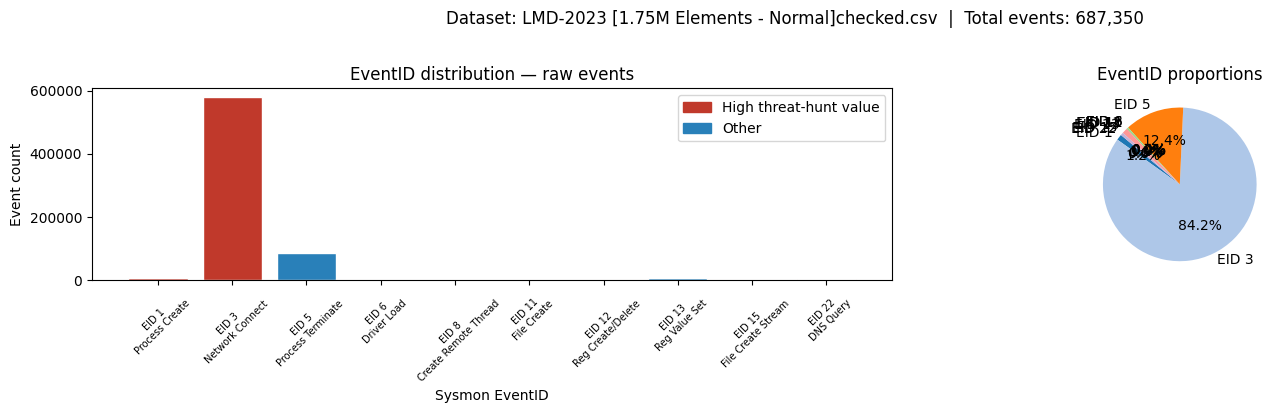


Dataset note: filename contains "[Normal]" — all Label=0 (benign baseline).
This is the normal-only subset of LMD-2023.
For ground-truth evaluation the attack subset would be merged.


In [28]:

# Sysmon EventID descriptions
EVENTID_NAMES = {
    1: 'Process Create', 2: 'File Change Time', 3: 'Network Connect',
    4: 'Sysmon State', 5: 'Process Terminate', 6: 'Driver Load',
    7: 'Image Load', 8: 'Create Remote Thread', 9: 'Raw Disk Access',
    10: 'Process Access', 11: 'File Create', 12: 'Reg Create/Delete',
    13: 'Reg Value Set', 14: 'Reg Rename', 15: 'File Create Stream',
    16: 'Sysmon Config', 17: 'Pipe Created', 18: 'Pipe Connect',
    22: 'DNS Query', 23: 'File Delete', 25: 'Process Tamper',
}

eid_counts = df['event_id'].value_counts().sort_index()
eid_labels = [f"EID {eid}\n{EVENTID_NAMES.get(eid, '')}" for eid in eid_counts.index]

# colour-code high-value threat-hunting EIDs
threat_eids = {1, 3, 7, 8, 10, 22}  # lateral movement / injection / C2
colors = ['#c0392b' if eid in threat_eids else '#2980b9' for eid in eid_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].bar(eid_labels, eid_counts.values, color=colors, edgecolor='white')
axes[0].set_xlabel('Sysmon EventID')
axes[0].set_ylabel('Event count')
axes[0].set_title('EventID distribution — raw events')
axes[0].tick_params(axis='x', rotation=45, labelsize=7)
from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color='#c0392b', label='High threat-hunt value'),
    Patch(color='#2980b9', label='Other'),
])

# Proportion pie
axes[1].pie(eid_counts.values, labels=[f"EID {e}" for e in eid_counts.index],
            autopct='%1.1f%%', startangle=140,
            colors=plt.cm.tab20.colors[:len(eid_counts)])
axes[1].set_title('EventID proportions')

plt.suptitle(f'Dataset: {INPUT_PATH.name}  |  Total events: {len(df):,}', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nDataset note: filename contains "[Normal]" — all Label=0 (benign baseline).')
print('This is the normal-only subset of LMD-2023.')
print('For ground-truth evaluation the attack subset would be merged.')


## Step 2 — Windowing & Feature Extraction
Slice events into 60-second tumbling windows and compute 21 numerical features per window, plus raw event summaries for the LLM evidence pack.

Windows created : 1424
Feature matrix  : (1424, 17)


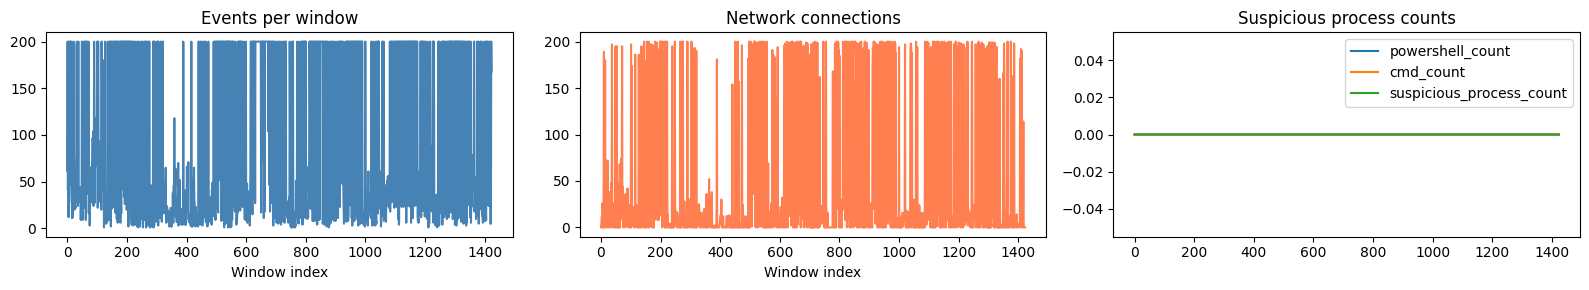

,event_count,unique_processes,network_connection_count,suspicious_process_count,powershell_count,event_id_entropy,process_entropy
count,1424.000000,1424.000000,1424.000000,1424.0,1424.0,1424.000000,1424.000000
mean,84.112360,4.892556,53.537921,0.0,0.0,0.950724,1.257794
std,84.234789,2.836436,80.459860,0.0,0.0,0.697658,0.918731
min,1.000000,1.000000,0.000000,0.0,0.0,0.000000,0.000000
25%,13.000000,3.000000,0.000000,0.0,0.0,0.230054,0.362338
50%,35.500000,4.000000,8.000000,0.0,0.0,0.983265,1.251629
75%,200.000000,7.000000,97.250000,0.0,0.0,1.533206,2.000000
max,200.000000,18.000000,200.000000,0.0,0.0,2.574165,3.807355


In [29]:
from preprocessor import make_windows

windows = list(make_windows(df, window_size_seconds=WINDOW_SECONDS, max_events=MAX_EVENTS_PER_WINDOW))
wdf = pd.DataFrame([w.to_dict() for w in windows])
X = np.array([w.to_feature_vector() for w in windows])

print(f'Windows created : {len(windows)}')
print(f'Feature matrix  : {X.shape}')

fig, axes = plt.subplots(1, 3, figsize=(16, 3))
wdf['event_count'].plot(ax=axes[0], title='Events per window', color='steelblue')
axes[0].set_xlabel('Window index')
wdf['network_connection_count'].plot(ax=axes[1], title='Network connections', color='coral')
axes[1].set_xlabel('Window index')
wdf[['powershell_count', 'cmd_count', 'suspicious_process_count']].plot(ax=axes[2], title='Suspicious process counts')
plt.tight_layout()
plt.show()

wdf[['event_count', 'unique_processes', 'network_connection_count',
     'suspicious_process_count', 'powershell_count', 'has_mimikatz', 'has_psexec',
     'event_id_entropy', 'process_entropy']].describe()

### Step 2 — Feature Correlation Heatmap
Examines linear correlation between the 17 engineered features. Highly correlated pairs are redundant; near-zero correlations confirm the feature set adds independent signal. This informs both model behaviour and feature selection decisions.

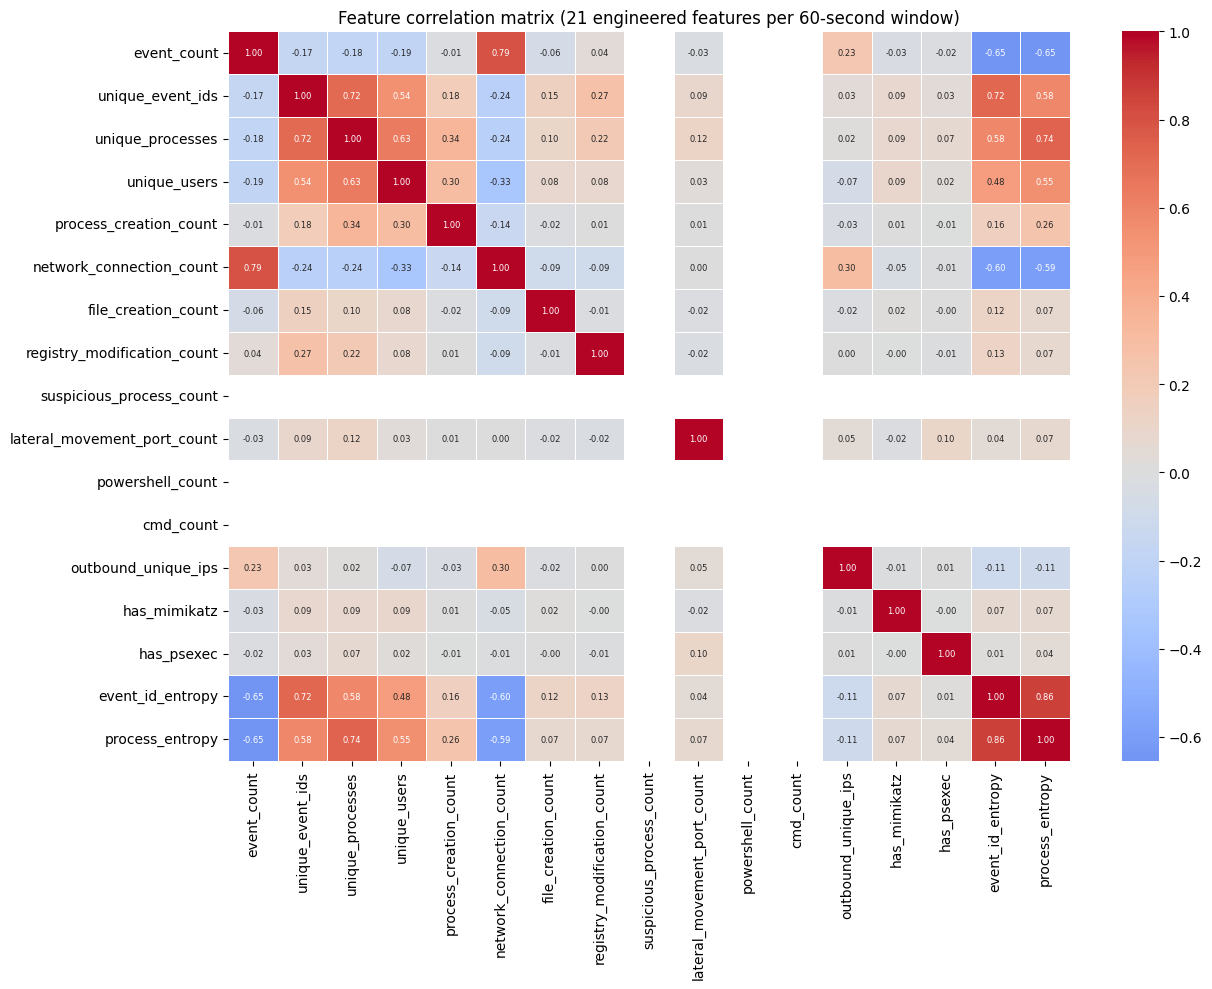

Strongly correlated feature pairs (|r| > 0.5):
  event_id_entropy ↔ process_entropy  r=0.859
  event_count ↔ network_connection_count  r=0.794
  unique_processes ↔ process_entropy  r=0.742
  unique_event_ids ↔ event_id_entropy  r=0.722
  unique_event_ids ↔ unique_processes  r=0.715
  event_count ↔ event_id_entropy  r=0.654
  event_count ↔ process_entropy  r=0.648
  unique_processes ↔ unique_users  r=0.632
  network_connection_count ↔ event_id_entropy  r=0.595
  network_connection_count ↔ process_entropy  r=0.591
  unique_event_ids ↔ process_entropy  r=0.584
  unique_processes ↔ event_id_entropy  r=0.583
  unique_users ↔ process_entropy  r=0.551
  unique_event_ids ↔ unique_users  r=0.545


In [30]:
try:
    import seaborn as sns
    _has_seaborn = True
except ImportError:
    _has_seaborn = False

# Feature names — must match WindowFeatures.to_feature_vector() order exactly
FEATURE_NAMES = [
    'event_count',                  # 0
    'unique_event_ids',             # 1
    'unique_processes',             # 2
    'unique_users',                 # 3
    'process_creation_count',       # 4  EID 1
    'network_connection_count',     # 5  EID 3
    'file_creation_count',          # 6  EID 11
    'registry_modification_count',  # 7  EID 13
    'suspicious_process_count',     # 8
    'lateral_movement_port_count',  # 9
    'powershell_count',             # 10
    'cmd_count',                    # 11
    'outbound_unique_ips',          # 12
    'has_mimikatz',                 # 13
    'has_psexec',                   # 14
    'event_id_entropy',             # 15
    'process_entropy',              # 16
    'remote_thread_count',          # 17 EID 8  (process injection)
    'process_access_count',         # 18 EID 10 (LSASS access)
    'driver_load_count',            # 19 EID 6  (rootkit / tamper)
    'file_delete_count',            # 20 EID 23 (destruction / ransomware)
]
feat_cols = FEATURE_NAMES[:X.shape[1]]

feat_df = pd.DataFrame(X, columns=feat_cols)
corr = feat_df.corr()

fig, ax = plt.subplots(figsize=(13, 10))
if _has_seaborn:
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                linewidths=0.4, ax=ax, annot_kws={'size': 6})
else:
    im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
    ax.set_xticks(range(len(feat_cols)))
    ax.set_yticks(range(len(feat_cols)))
    ax.set_xticklabels(feat_cols, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(feat_cols, fontsize=8)
    plt.colorbar(im, ax=ax, label='Pearson r')

ax.set_title('Feature correlation matrix (21 engineered features per 60-second window)')
plt.tight_layout()
plt.show()

# Report the strongest correlations (|r| > 0.5)
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
strong = upper.stack().abs().sort_values(ascending=False)
strong = strong[strong > 0.5]
if not strong.empty:
    print('Strongly correlated feature pairs (|r| > 0.5):')
    for (a, b), r in strong.items():
        print(f'  {a} ↔ {b}  r={r:.3f}')
else:
    print('No strongly correlated feature pairs (all |r| ≤ 0.5) — feature set is well-diversified.')


## Step 3 — IsolationForest  *(skipped: `--skip-detectors`)*
When `SKIP_DETECTORS=True` all `if_score` values are set to `0.0`. The cell below runs the detector anyway in **inspect mode** (results are not used for escalation) so you can see what it would have flagged.

INFO detectors: IForestDetector fitted on 1424 samples


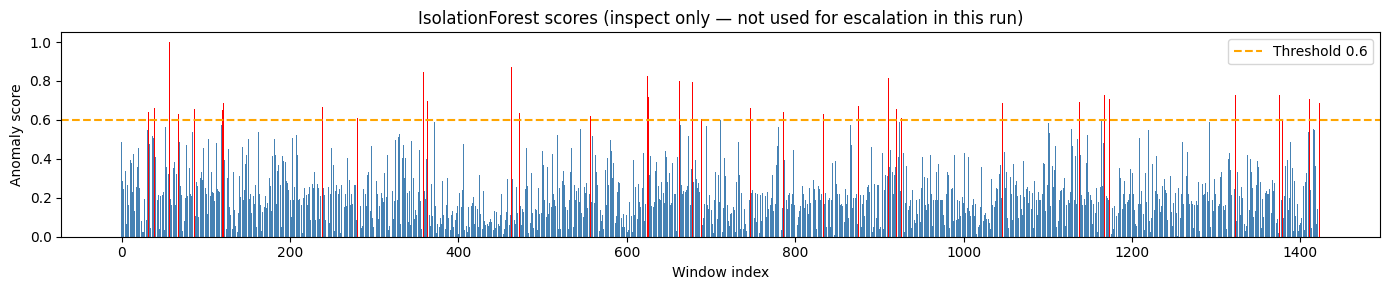

[Inspect] Windows IF score > 0.6: 60/1424
NOTE: if_scores are zeroed for the actual pipeline run (SKIP_DETECTORS=True)


In [31]:
from detectors import IForestDetector

if_scores = np.zeros(len(windows))   # zeroed — SKIP_DETECTORS mode

# ── Inspect-only (not used for escalation) ─────────────────────────────────
iforest_inspect = IForestDetector()
iforest_inspect.fit(X)
if_scores_inspect = iforest_inspect.score(X)

fig, ax = plt.subplots(figsize=(14, 3))
ax.bar(range(len(if_scores_inspect)),
       if_scores_inspect,
       color=['red' if s > 0.6 else 'steelblue' for s in if_scores_inspect])
ax.axhline(0.6, color='orange', linestyle='--', label='Threshold 0.6')
ax.set_xlabel('Window index')
ax.set_ylabel('Anomaly score')
ax.set_title('IsolationForest scores (inspect only — not used for escalation in this run)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'[Inspect] Windows IF score > 0.6: {(if_scores_inspect > 0.6).sum()}/{len(windows)}')
print('NOTE: if_scores are zeroed for the actual pipeline run (SKIP_DETECTORS=True)')

## Step 4 — GRU Autoencoder  *(skipped: `--skip-detectors`)*
`gru_scores` are set to `0.0`. No model is trained in this mode.

In [32]:
gru_scores = np.zeros(len(windows))   # zeroed — SKIP_DETECTORS mode
print('GRU skipped (SKIP_DETECTORS=True). gru_scores = all zeros.')

GRU skipped (SKIP_DETECTORS=True). gru_scores = all zeros.


## Step 5 — ATT&CK Rule Tagger + Ensemble Score
The rule tagger always runs. With detectors skipped, `ensemble_score` is driven by ATT&CK rule hits only (max possible score = 0.2). All windows pass the `THRESHOLD=0.0` filter.

Ensemble weights: IF×0.5 + GRU×0.3 + rule_hit×0.2

Windows above threshold (0.0): 1424/1424
Saved → results\2026-03-26_19-51\windows_scored.json


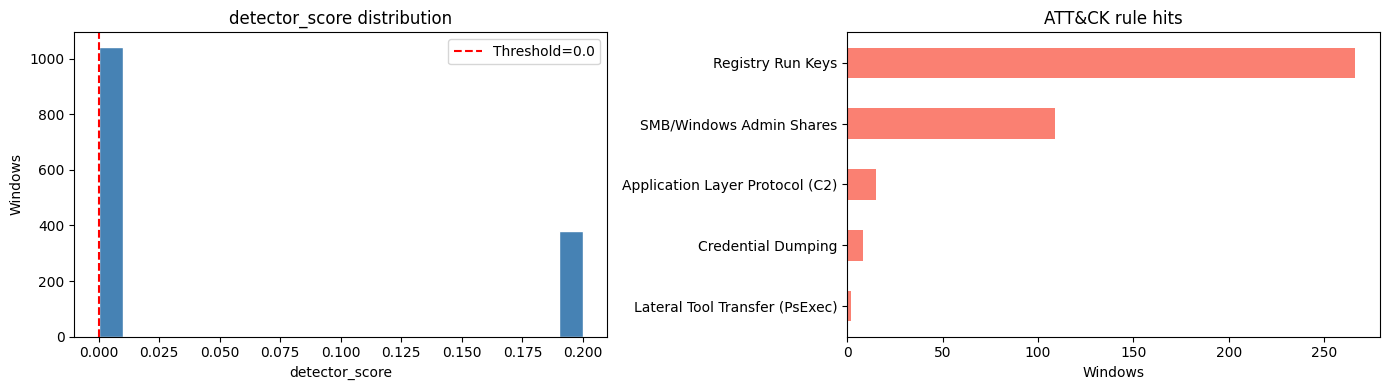

In [33]:
from detectors import tag_techniques, ensemble_score

window_dicts = []
for i, w in enumerate(windows):
    wd = w.to_dict()
    wd['attck_hits'] = tag_techniques(wd)
    wd['if_score']   = float(if_scores[i])
    wd['gru_score']  = float(gru_scores[i])
    wd['detector_score'] = ensemble_score(
        iforest_score=float(if_scores[i]),
        gru_score=float(gru_scores[i]),
        has_attck_hits=len(wd['attck_hits']) > 0,
    )
    window_dicts.append(wd)

wdf['detector_score'] = [w['detector_score'] for w in window_dicts]
wdf['attck_hit_count'] = [len(w['attck_hits']) for w in window_dicts]

# Save windows_scored.json
ws_path = OUTPUT_DIR / 'windows_scored.json'
with open(ws_path, 'w') as f:
    json.dump(window_dicts, f, indent=2, default=str)

high_risk = sum(1 for w in window_dicts if w['detector_score'] >= THRESHOLD)
print(f'Windows above threshold ({THRESHOLD}): {high_risk}/{len(window_dicts)}')
print(f'Saved → {ws_path}')

# Score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

score_values = wdf['detector_score']
axes[0].hist(score_values, bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(THRESHOLD, color='red', linestyle='--', label=f'Threshold={THRESHOLD}')
axes[0].set_xlabel('detector_score')
axes[0].set_ylabel('Windows')
axes[0].set_title('detector_score distribution')
axes[0].legend()

# ATT&CK techniques fired
from collections import Counter
tech_counts = Counter(
    h['name']
    for w in window_dicts for h in w['attck_hits']
)
if tech_counts:
    tc_s = pd.Series(tech_counts).sort_values()
    tc_s.plot(kind='barh', ax=axes[1], color='salmon', title='ATT&CK rule hits')
    axes[1].set_xlabel('Windows')
else:
    axes[1].text(0.5, 0.5, 'No ATT&CK rule hits', ha='center', va='center')
    axes[1].set_title('ATT&CK rule hits')

plt.tight_layout()
plt.show()

### Step 5 — Temporal Anomaly Timeline
Scores plotted against real wall-clock time. Windows above the escalation threshold are highlighted. Bursts of elevated scores indicate temporal clustering of suspicious activity — a key indicator of coordinated attack behaviour.

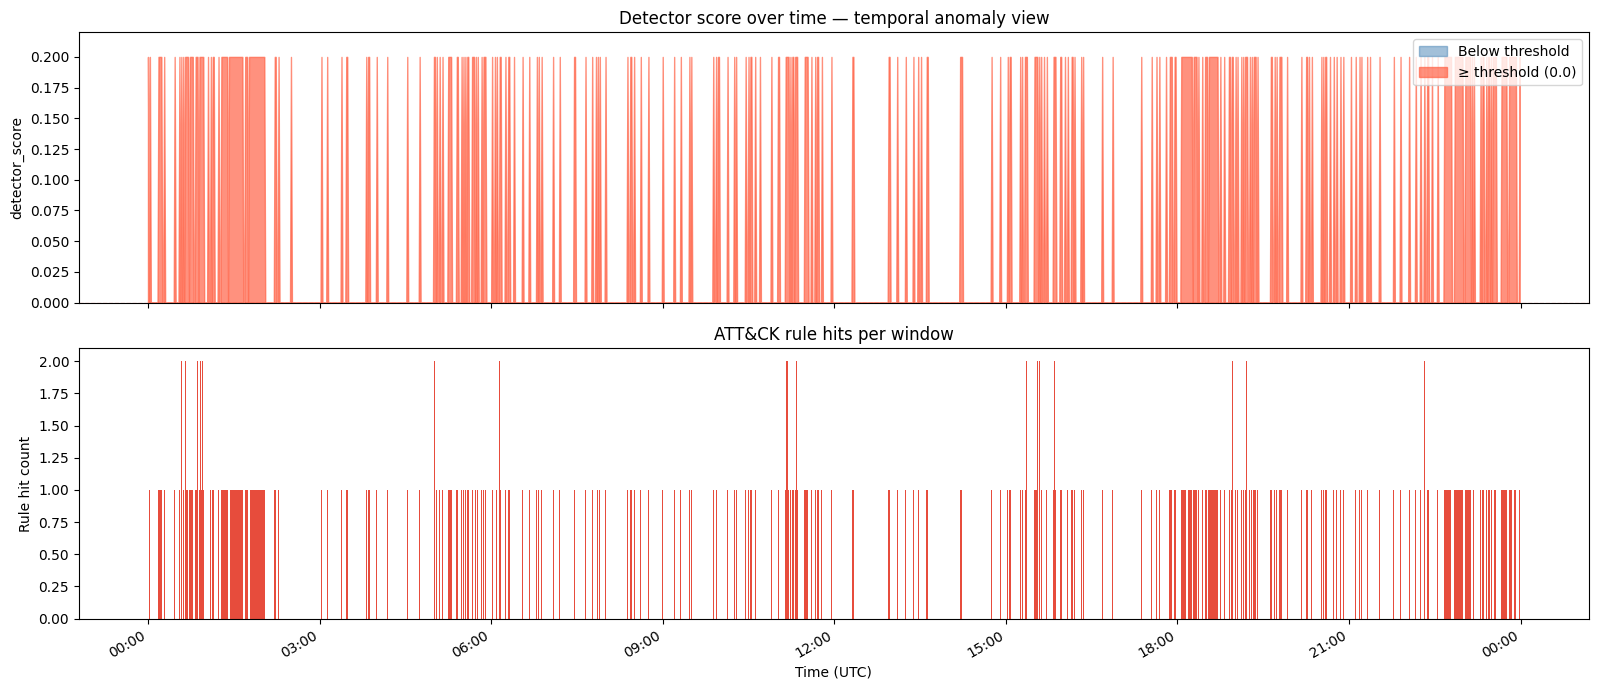

Time span      : 2026-03-26 00:00:00+00:00  →  2026-03-26 23:59:00+00:00
Flagged windows: 1424 / 1424  (100.0%)
Windows with ATT&CK hits: 381 / 1424


In [34]:

_times  = pd.to_datetime(wdf['window_start'], utc=True, errors='coerce')
_scores = wdf['detector_score'].values
_hits   = wdf['attck_hit_count'].values

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

# Top: detector_score over time
_flagged = _scores >= THRESHOLD
axes[0].fill_between(_times, 0, _scores, where=~_flagged,
                     color='steelblue', alpha=0.5, label='Below threshold')
axes[0].fill_between(_times, 0, _scores, where=_flagged,
                     color='tomato', alpha=0.7, label=f'≥ threshold ({THRESHOLD})')
axes[0].axhline(THRESHOLD, color='red', linestyle='--', linewidth=0.8)
axes[0].set_ylabel('detector_score')
axes[0].set_title('Detector score over time — temporal anomaly view')
axes[0].legend(loc='upper right')
axes[0].set_ylim(0, max(_scores.max() * 1.1, THRESHOLD * 1.5))

# Bottom: ATT&CK rule hits per window
axes[1].bar(_times, _hits, width=pd.Timedelta(seconds=55),
            color=['#e74c3c' if h > 0 else '#bdc3c7' for h in _hits],
            label='ATT&CK rule hits')
axes[1].set_ylabel('Rule hit count')
axes[1].set_xlabel('Time (UTC)')
axes[1].set_title('ATT&CK rule hits per window')

import matplotlib.dates as mdates
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

print(f'Time span      : {_times.min()}  →  {_times.max()}')
print(f'Flagged windows: {_flagged.sum()} / {len(windows)}  ({100*_flagged.mean():.1f}%)')
print(f'Windows with ATT&CK hits: {(_hits > 0).sum()} / {len(windows)}')


## Pre-flight — Ollama model check
Run this cell before Steps 6a/6b. It lists every model Ollama has pulled and raises a clear error if `SLM_MODEL` or `JUDGE_MODEL` is missing — preventing 1,424 silent 404 failures.

In [35]:
import ollama as _ollama

_models_raw = _ollama.list().models
# Build a set of every form a model name can be referenced:
# 'llama3.2:latest' ← stored name
# 'llama3.2'        ← bare name (Ollama accepts this; appends :latest implicitly)
_all_forms = set()
for m in _models_raw:
    full = m.model                          # e.g. 'llama3.2:latest'
    _all_forms.add(full)
    base = full.split(':')[0]               # e.g. 'llama3.2'
    tag  = full.split(':')[1] if ':' in full else 'latest'
    _all_forms.add(base)                    # bare name
    if tag == 'latest':
        _all_forms.add(base + ':latest')    # explicit :latest

print('Models available in Ollama:')
for m in sorted(m.model for m in _models_raw):
    print(f'  ✓ {m}')

_missing = []
for label, model in [('SLM_MODEL', SLM_MODEL), ('JUDGE_MODEL', JUDGE_MODEL)]:
    if model not in _all_forms:
        _missing.append((label, model))

if _missing:
    for label, model in _missing:
        print(f'\n✗ {label}={model!r} — NOT found in Ollama.')
        print(f'  → Pull it with:  ollama pull {model}')
    raise RuntimeError(
        f"Required models not pulled: {[m for _, m in _missing]}. "
        "Run the pull commands above in a terminal, then re-run this cell."
    )
else:
    print(f'\n✓ {SLM_MODEL!r} ready')
    print(f'✓ {JUDGE_MODEL!r} ready')
    print('\nAll required models found — proceed to Step 6a.')


INFO httpx: HTTP Request: GET http://127.0.0.1:11434/api/tags "HTTP/1.1 200 OK"


Models available in Ollama:
  ✓ llama3.2:latest
  ✓ phi3:medium
  ✓ phi3:mini
  ✓ qwen3:8b

✓ 'phi3:medium' ready
✓ 'llama3.2' ready

All required models found — proceed to Step 6a.


## Step 6a — SLM Analyst (`phi3:mini`)

Sends every window above `THRESHOLD` through the SLM for rapid first-pass triage. A trivially-benign pre-filter skips Ollama for windows with zero threat signals.

> **This cell calls Ollama.** Make sure `ollama serve` is running and `phi3:mini` is pulled.
> Interrupt the kernel to abort mid-run; already-collected results will not be saved.

INFO httpx: HTTP Request: GET http://127.0.0.1:11434/api/tags "HTTP/1.1 200 OK"
INFO slm_analyst: SLM analyst: 1424/1424 janelas acima do threshold (0.0)
INFO httpx: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: POST http:

SLM analyses   : 1424
Pre-filtered   : 500  (no Ollama call)
Ollama calls   : 924
Saved → results\2026-03-26_19-51\slm_analyses.json


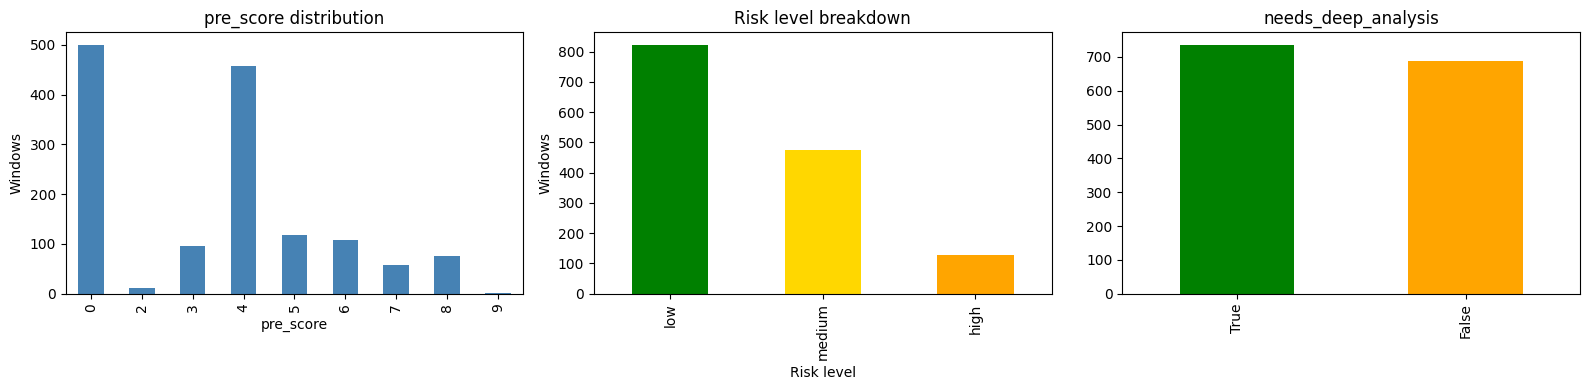

,window_start,pre_score,risk_level,needs_deep_analysis,summary
23,2026-03-26T00:55:00+00:00,9,high,True,The presence of Mimikatz and multiple registry...
777,2026-03-26T09:08:00+00:00,8,high,True,The log window shows an unusually high number ...
779,2026-03-26T09:10:00+00:00,8,high,True,The log window shows an unusually high number ...
774,2026-03-26T09:05:00+00:00,8,high,True,The high number of network connections and out...
757,2026-03-26T08:47:00+00:00,8,high,True,The log window shows a high volume of network ...
859,2026-03-26T10:47:00+00:00,8,high,True,The log window shows an unusually high number ...
775,2026-03-26T09:06:00+00:00,8,high,True,The log window shows an unusually high number ...
888,2026-03-26T11:33:00+00:00,8,high,True,The log window shows an unusually high number ...
885,2026-03-26T11:26:00+00:00,8,high,True,The log window shows a high volume of network ...
879,2026-03-26T11:15:00+00:00,8,high,True,The log window shows an unusually high number ...


In [36]:
from slm_analyst import SLMAnalyst

analyst = SLMAnalyst(model=SLM_MODEL)
slm_analyses = analyst.analyse_batch(window_dicts, threshold=THRESHOLD)

slm_path = OUTPUT_DIR / 'slm_analyses.json'
with open(slm_path, 'w') as f:
    json.dump([a.to_dict() for a in slm_analyses], f, indent=2, default=str)

sdf = pd.DataFrame([a.to_dict() for a in slm_analyses])
prefiltered = sdf['summary'].str.contains('pre-filter', na=False).sum()

print(f'SLM analyses   : {len(sdf)}')
print(f'Pre-filtered   : {prefiltered}  (no Ollama call)')
print(f'Ollama calls   : {len(sdf) - prefiltered}')
print(f'Saved → {slm_path}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sdf['pre_score'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', title='pre_score distribution')
axes[0].set_xlabel('pre_score')
axes[0].set_ylabel('Windows')

color_map = {'low': 'green', 'medium': 'gold', 'high': 'orange', 'critical': 'red'}
rl = sdf['risk_level'].value_counts()
rl.plot(kind='bar', ax=axes[1],
        color=[color_map.get(l, 'grey') for l in rl.index],
        title='Risk level breakdown')
axes[1].set_xlabel('Risk level')
axes[1].set_ylabel('Windows')

sdf['needs_deep_analysis'].value_counts().plot(
    kind='bar', ax=axes[2], color=['green', 'orange'],
    title='needs_deep_analysis')
axes[2].set_xlabel('')

plt.tight_layout()
plt.show()

cols = [c for c in ['window_start', 'pre_score', 'risk_level',
                     'needs_deep_analysis', 'summary'] if c in sdf.columns]
sdf[cols].sort_values('pre_score', ascending=False).head(20)

## Step 6b — LLM Judge (`llama3.2`)

Validates the SLM pre-diagnoses against the full evidence pack. Only the top `MAX_JUDGE_WINDOWS` (50) windows by `(detector_score, SLM pre_score)` are judged. Windows with `pre_score < 3` and `needs_deep_analysis=False` are skipped.

> **This cell calls Ollama.** Make sure `llama3.2` is pulled.

INFO httpx: HTTP Request: GET http://127.0.0.1:11434/api/tags "HTTP/1.1 200 OK"
INFO llm_judge: LLM Judge: 50/1424 janelas (threshold=0.0, max=50)
INFO httpx: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: POST http://127.0

Judge results: 50
Saved → results\2026-03-26_19-51\judge_results.json


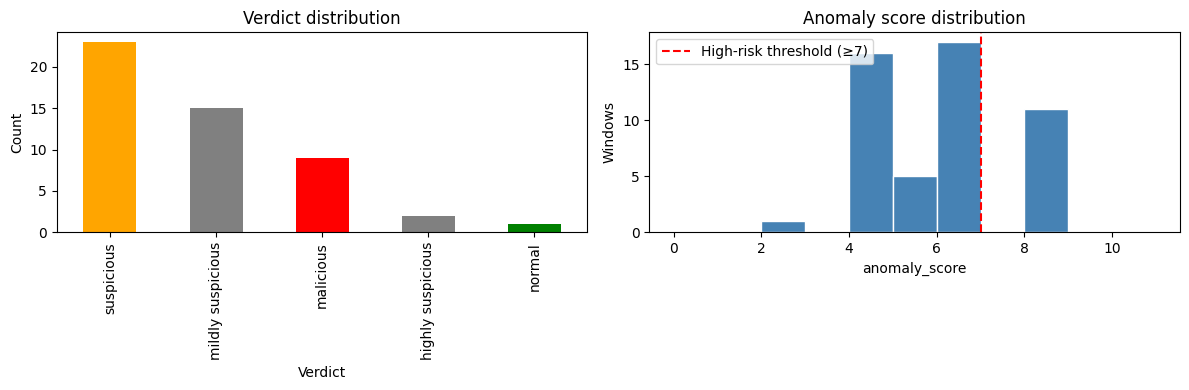

In [37]:
from llm_judge import LLMJudge

judge = LLMJudge(model=JUDGE_MODEL)
judge_results = judge.judge_batch(
    window_dicts,
    slm_analyses=slm_analyses,
    threshold=THRESHOLD,
    max_windows=MAX_JUDGE_WINDOWS,
)

judge_path = OUTPUT_DIR / 'judge_results.json'
with open(judge_path, 'w') as f:
    json.dump([r.to_dict() for r in judge_results], f, indent=2, default=str)

print(f'Judge results: {len(judge_results)}')
print(f'Saved → {judge_path}')

if judge_results:
    jdf = pd.DataFrame([r.to_dict() for r in judge_results])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    verdict_colors = {'normal': 'green', 'suspicious': 'orange', 'malicious': 'red'}
    vc = jdf['verdict'].value_counts()
    vc.plot(kind='bar', ax=axes[0],
            color=[verdict_colors.get(v, 'grey') for v in vc.index],
            title='Verdict distribution')
    axes[0].set_xlabel('Verdict')
    axes[0].set_ylabel('Count')

    axes[1].hist(jdf['anomaly_score'], bins=range(12), color='steelblue', edgecolor='white')
    axes[1].axvline(7, color='red', linestyle='--', label='High-risk threshold (≥7)')
    axes[1].set_xlabel('anomaly_score')
    axes[1].set_ylabel('Windows')
    axes[1].set_title('Anomaly score distribution')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    cols = [c for c in ['window_start', 'anomaly_score', 'verdict',
                         'slm_pre_score', 'detector_score', 'fp_risk'] if c in jdf.columns]
    jdf[cols].sort_values('anomaly_score', ascending=False)
else:
    print('No windows reached the Judge (all cleared by the SLM pre-filter or pre_score < 3).')

### Step 6b — ATT&CK Technique Heatmap
Maps each flagged window (rows) against MITRE ATT&CK techniques detected (columns). Colour intensity reflects judge confidence. This is the most presentation-ready view for a SOC analyst or academic evaluator.

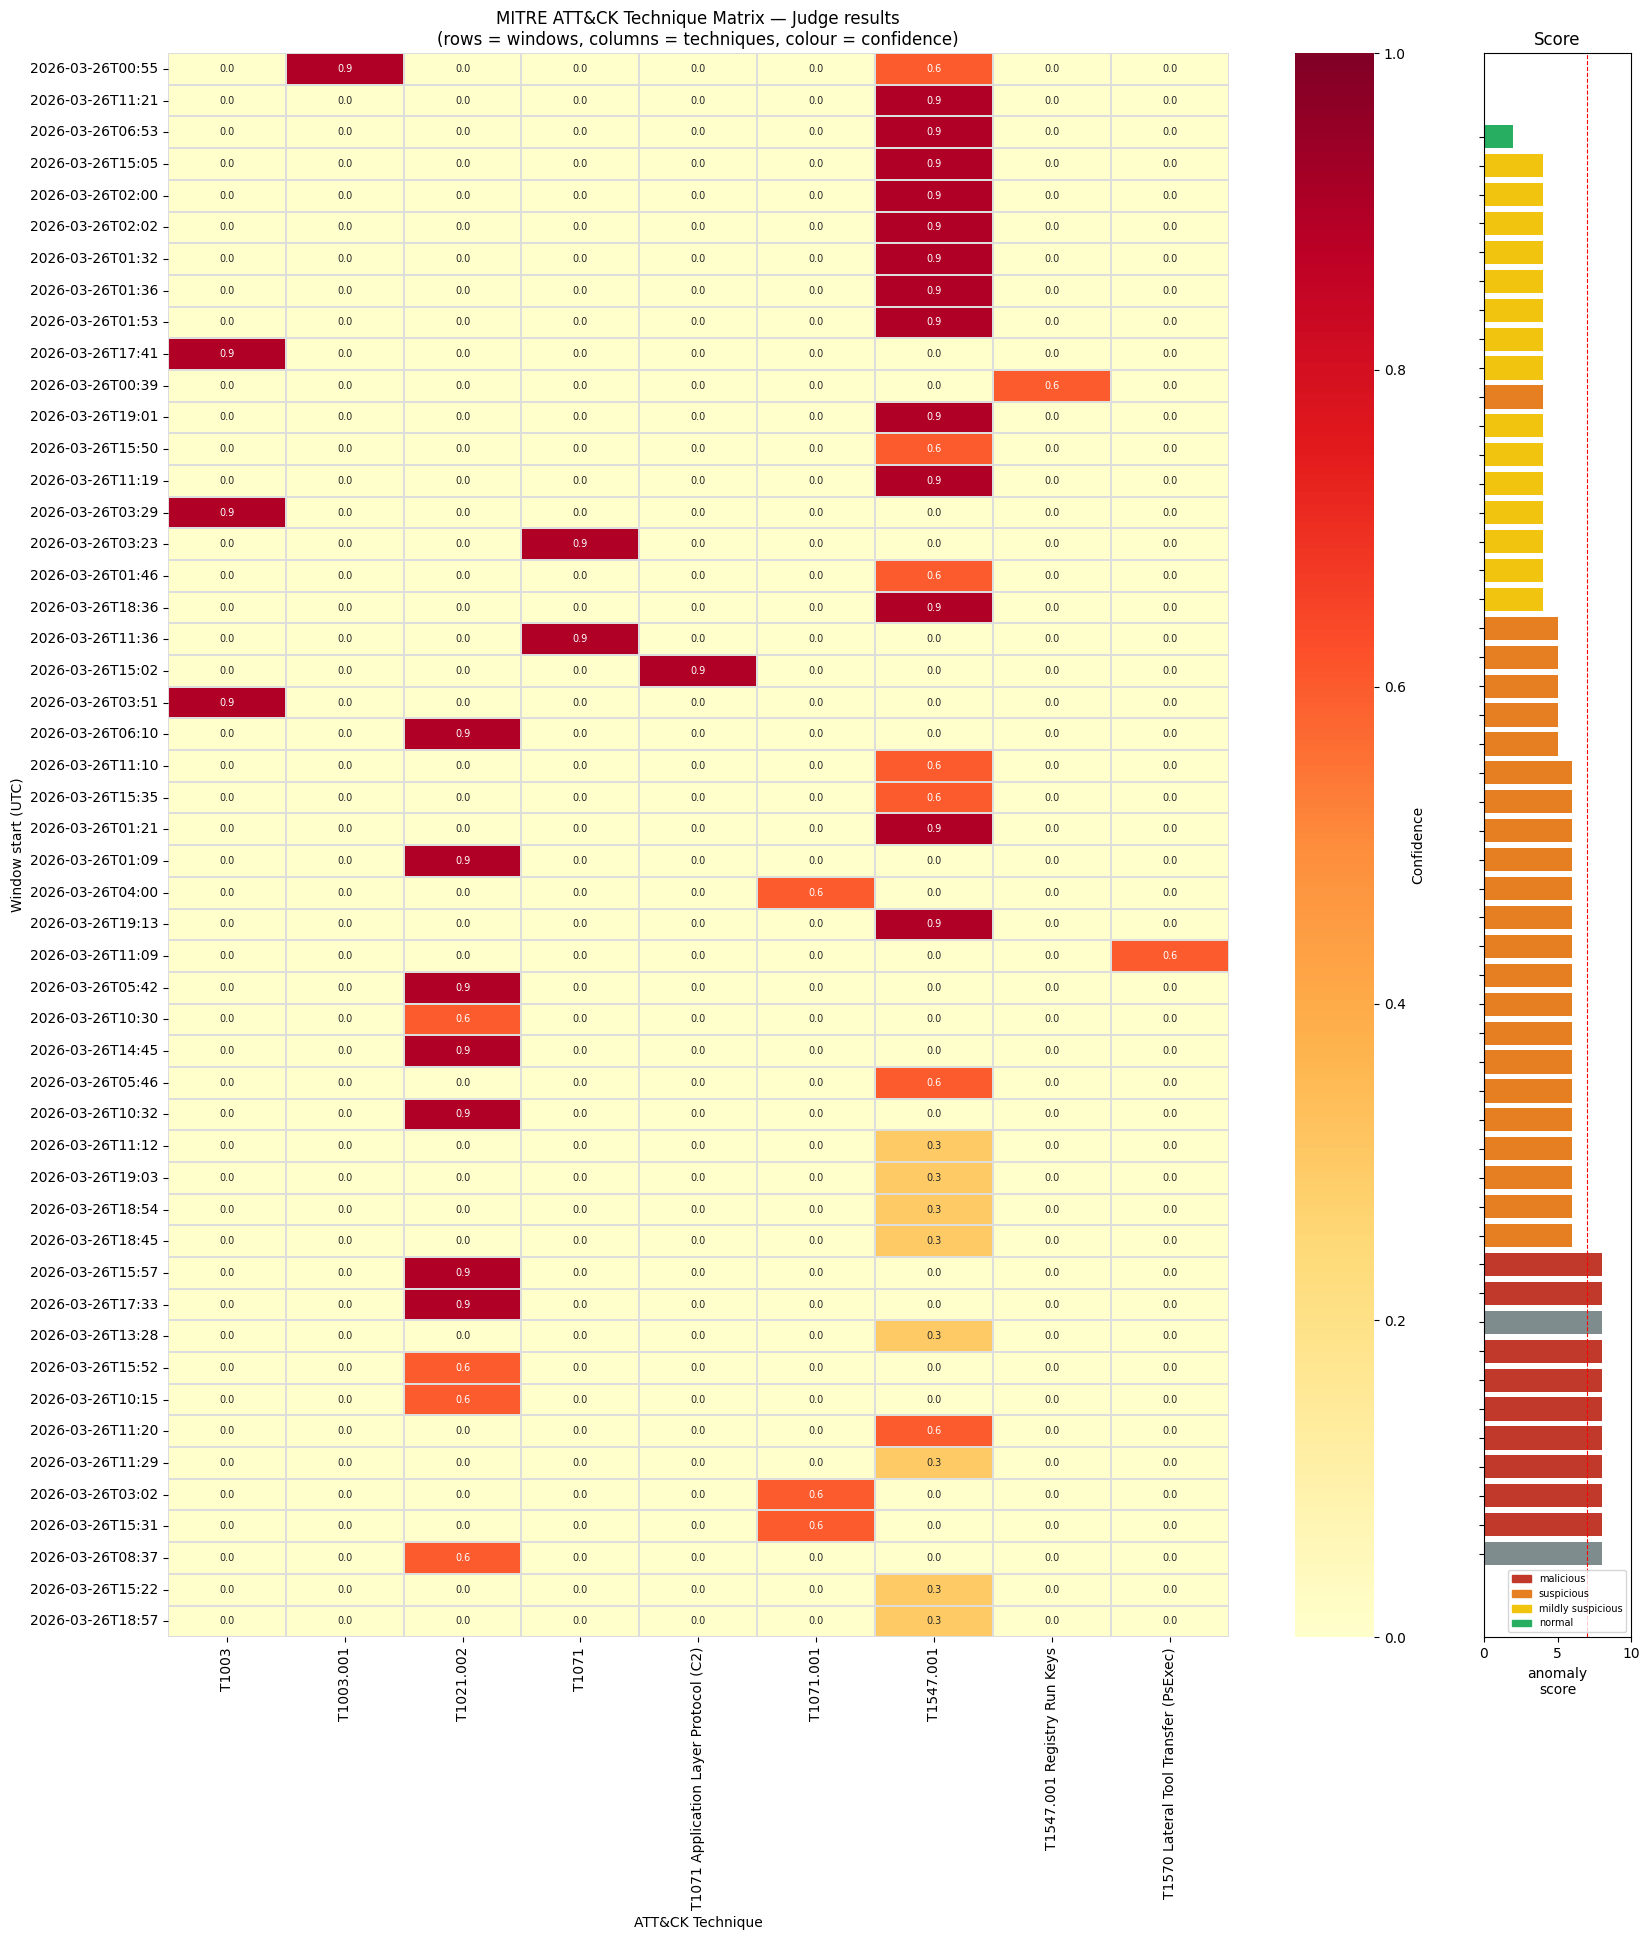

In [38]:

if judge_results:
    # Build a window × technique matrix (confidence values)
    # Use judge techniques; fall back to ATT&CK rule hits for non-judged windows
    all_techniques = sorted({
        t['technique_id'] if 'technique_id' in t else t.get('name', '?')
        for r in judge_results for t in r.techniques
    })

    rows = []
    for r in judge_results:
        row = {tid: 0.0 for tid in all_techniques}
        for t in r.techniques:
            tid = t.get('technique_id') or t.get('name', '?')
            conf_raw = t.get('confidence', 'medium')
            conf = {'low': 0.3, 'medium': 0.6, 'high': 0.9}.get(
                str(conf_raw).lower(), float(conf_raw) if str(conf_raw).replace('.','').isdigit() else 0.5
            )
            row[tid] = max(row.get(tid, 0), conf)
        row['_window'] = str(r.window_start)[:16]
        row['_verdict'] = r.verdict
        row['_score']   = r.anomaly_score
        rows.append(row)

    hmap_df = pd.DataFrame(rows).set_index('_window')
    verdict_col = hmap_df.pop('_verdict')
    score_col   = hmap_df.pop('_score')
    hmap_data   = hmap_df[all_techniques].astype(float)

    # Sort by anomaly_score descending
    hmap_data = hmap_data.loc[score_col.sort_values(ascending=False).index]
    verdict_col = verdict_col.loc[hmap_data.index]
    score_col   = score_col.loc[hmap_data.index]

    fig, axes = plt.subplots(1, 2, figsize=(max(12, len(all_techniques)*1.4+4), max(5, len(rows)*0.35+2)),
                             gridspec_kw={'width_ratios': [len(all_techniques), 1]})

    if _has_seaborn:
        sns.heatmap(hmap_data, ax=axes[0], cmap='YlOrRd', vmin=0, vmax=1,
                    linewidths=0.3, linecolor='#ddd', annot=len(all_techniques) <= 12,
                    fmt='.1f', annot_kws={'size': 7}, cbar_kws={'label': 'Confidence'})
    else:
        im = axes[0].imshow(hmap_data.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
        axes[0].set_xticks(range(len(all_techniques)))
        axes[0].set_yticks(range(len(hmap_data)))
        axes[0].set_xticklabels(hmap_data.columns, rotation=45, ha='right', fontsize=8)
        axes[0].set_yticklabels(hmap_data.index, fontsize=7)
        plt.colorbar(im, ax=axes[0], label='Confidence')

    axes[0].set_title('MITRE ATT&CK Technique Matrix — Judge results\n(rows = windows, columns = techniques, colour = confidence)')
    axes[0].set_xlabel('ATT&CK Technique')
    axes[0].set_ylabel('Window start (UTC)')

    # Side bar: anomaly_score
    verdict_palette = {'malicious': '#c0392b', 'suspicious': '#e67e22',
                       'mildly suspicious': '#f1c40f', 'normal': '#27ae60'}
    bar_colors = [verdict_palette.get(v, '#7f8c8d') for v in verdict_col]
    axes[1].barh(range(len(score_col)), score_col.values, color=bar_colors, align='center')
    axes[1].set_yticks(range(len(score_col)))
    axes[1].set_yticklabels([])
    axes[1].set_xlim(0, 10)
    axes[1].set_xlabel('anomaly\nscore')
    axes[1].set_title('Score')
    axes[1].axvline(7, color='red', linestyle='--', linewidth=0.8)

    from matplotlib.patches import Patch
    axes[1].legend(handles=[Patch(color=c, label=v) for v, c in verdict_palette.items()],
                   loc='lower right', fontsize=7)

    plt.tight_layout()
    plt.show()
else:
    print('No judge results — run Step 6b first.')


## Step 7 — Report
Generates the same Markdown report as the CLI pipeline.

In [39]:
from pipeline import generate_report

report_path = generate_report(window_dicts, judge_results, OUTPUT_DIR, DATASET)
print(f'Report saved → {report_path}')

# Print a preview
text = report_path.read_text(encoding='utf-8')
print('\n' + '─' * 60)
print(text[:3000])
if len(text) > 3000:
    print(f'\n... (truncated, full report at {report_path})')

Report saved → results\2026-03-26_19-51\report_lmd_2026-03-26_21-11.md

────────────────────────────────────────────────────────────
# MEIA Challenge 3 — Anomaly Detection Report

**Dataset:** lmd  
**Generated:** 2026-03-26T21:11:28.504207  
**Total windows analysed:** 1424  
**Windows sent to judge:** 50  

## Summary

| Verdict | Count |
|---|---|
| Malicious | 9 |
| Suspicious | 23 |
| Normal | 1 |

## Top ATT&CK Techniques

| Technique | Count |
|---|---|
| T1547.001 | 28 |
| T1021.002 | 11 |
| T1071.001 | 3 |
| T1003 | 3 |
| T1071 | 2 |
| T1003.001 | 1 |
| T1547.001 Registry Run Keys | 1 |
| T1570 Lateral Tool Transfer (PsExec) | 1 |
| T1071 Application Layer Protocol (C2) | 1 |

## High-Risk Windows

### Window 2026-03-26T00:55:00+00:00 → 2026-03-26T00:56:00+00:00

**Score:** 8/10  
**Verdict:** highly suspicious  
**Detector score:** 0.200  
**FP risk:** high  

**Rationale:** The presence of Mimikatz and multiple registry modifications, along with high entropy scores and netwo

## Step 8 — Score Correlation
Cross-pipeline view: `detector_score` vs SLM `pre_score` vs Judge `anomaly_score`.

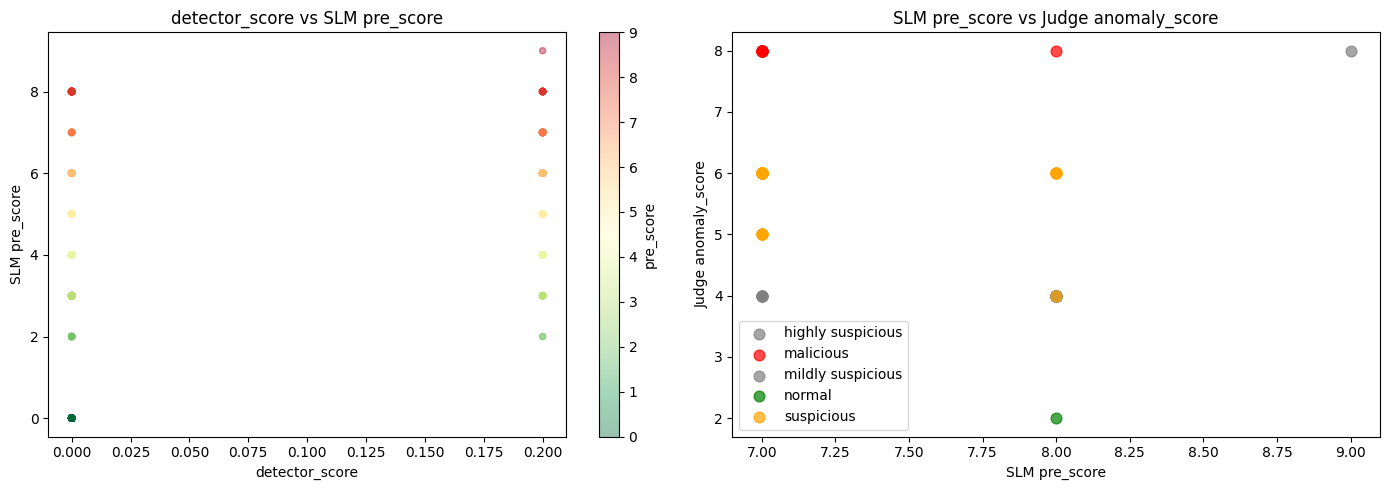

Correlation (detector_score ↔ SLM pre_score)     : 0.453
Correlation (SLM pre_score  ↔ Judge anomaly_score): -0.300


In [40]:
if judge_results:
    _ws  = pd.DataFrame(window_dicts)[['window_start', 'detector_score']]
    _slm = sdf[['window_start', 'pre_score', 'risk_level']]
    _j   = jdf[['window_start', 'anomaly_score', 'verdict']]

    slm_merged   = _ws.merge(_slm, on='window_start', how='inner')
    judge_merged = _slm.merge(_j,  on='window_start', how='inner')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sc = axes[0].scatter(slm_merged['detector_score'], slm_merged['pre_score'],
                         alpha=0.4, s=20, c=slm_merged['pre_score'], cmap='RdYlGn_r')
    plt.colorbar(sc, ax=axes[0], label='pre_score')
    axes[0].set_xlabel('detector_score')
    axes[0].set_ylabel('SLM pre_score')
    axes[0].set_title('detector_score vs SLM pre_score')

    verdict_colors = {'normal': 'green', 'suspicious': 'orange', 'malicious': 'red'}
    for verdict, group in judge_merged.groupby('verdict'):
        axes[1].scatter(group['pre_score'], group['anomaly_score'],
                        label=verdict, color=verdict_colors.get(verdict, 'grey'),
                        alpha=0.7, s=60)
    axes[1].set_xlabel('SLM pre_score')
    axes[1].set_ylabel('Judge anomaly_score')
    axes[1].set_title('SLM pre_score vs Judge anomaly_score')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    r1 = slm_merged['detector_score'].corr(slm_merged['pre_score'])
    r2 = judge_merged['pre_score'].corr(judge_merged['anomaly_score'])
    print(f'Correlation (detector_score ↔ SLM pre_score)     : {r1:.3f}')
    print(f'Correlation (SLM pre_score  ↔ Judge anomaly_score): {r2:.3f}')
else:
    print('No judge results — run Step 6b first.')

## Step 9 — Pipeline Funnel
Shows the filtering effect of each stage. A well-designed pipeline should dramatically reduce the number of windows a human analyst must inspect while retaining true positives.

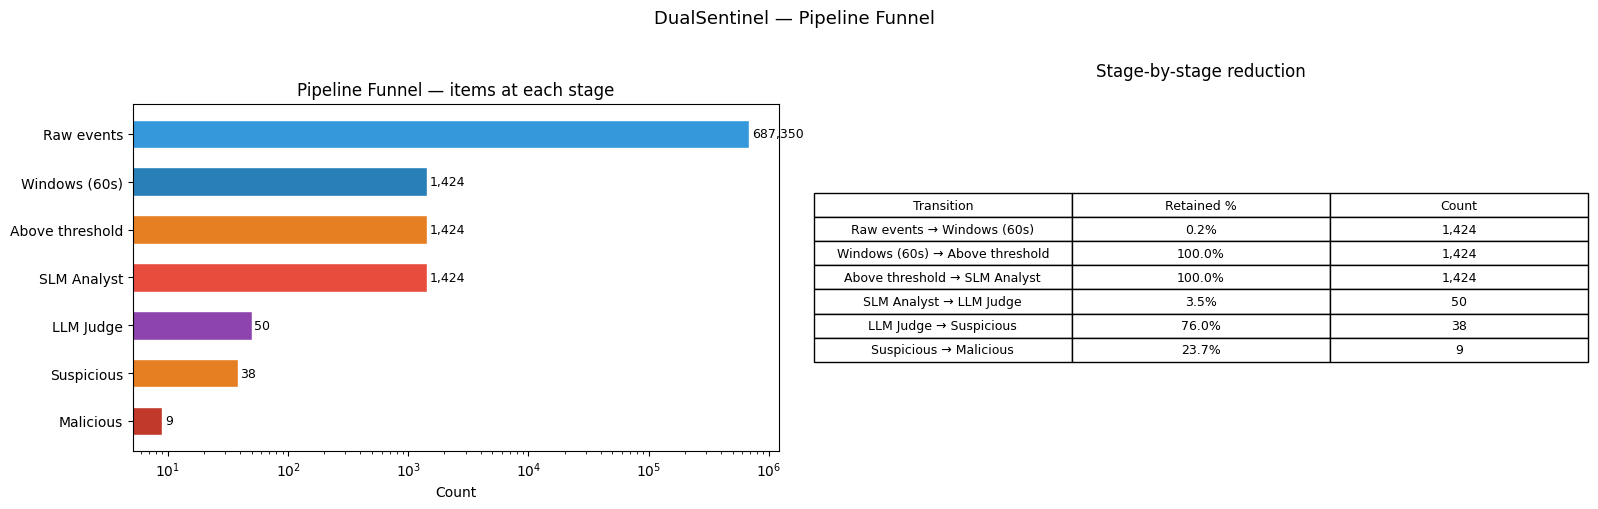

In [41]:

# ── Funnel counts ───────────────────────────────────────────────────────────
n_events       = len(df)
n_windows      = len(windows)
n_flagged      = sum(1 for w in window_dicts if w['detector_score'] >= THRESHOLD)
n_slm_analyzed = len(sdf) if 'sdf' in dir() else 0
n_slm_ollama   = (len(sdf) - sdf['summary'].str.contains('pre-filter', na=False).sum()) if n_slm_analyzed else 0
n_judged       = len(judge_results) if judge_results else 0
n_suspicious   = sum(1 for r in judge_results if r.verdict in ('suspicious', 'mildly suspicious')) if judge_results else 0
n_malicious    = sum(1 for r in judge_results if r.verdict == 'malicious') if judge_results else 0

stages = [
    ('Raw events',        n_events,       '#3498db'),
    ('Windows (60s)',     n_windows,      '#2980b9'),
    ('Above threshold',   n_flagged,      '#e67e22'),
    ('SLM Analyst',       n_slm_analyzed, '#e74c3c'),
    ('LLM Judge',         n_judged,       '#8e44ad'),
    ('Suspicious',        n_suspicious,   '#e67e22'),
    ('Malicious',         n_malicious,    '#c0392b'),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: horizontal funnel bar chart
labels = [s[0] for s in stages]
values = [s[1] for s in stages]
colors = [s[2] for s in stages]
y_pos  = range(len(stages))

bars = axes[0].barh(y_pos, values, color=colors, edgecolor='white', height=0.6)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(labels, fontsize=10)
axes[0].invert_yaxis()
axes[0].set_xlabel('Count')
axes[0].set_title('Pipeline Funnel — items at each stage')
axes[0].set_xscale('log')

for bar, val in zip(bars, values):
    if val > 0:
        axes[0].text(val * 1.05, bar.get_y() + bar.get_height()/2,
                     f'{val:,}', va='center', fontsize=9)

# Right: reduction ratio table
reduction = []
for i in range(1, len(stages)):
    prev = stages[i-1][1]
    curr = stages[i][1]
    ratio = curr / prev * 100 if prev > 0 else 0
    reduction.append((f"{stages[i-1][0]} → {stages[i][0]}", f'{ratio:.1f}%', f'{curr:,}'))

axes[1].axis('off')
tbl = axes[1].table(
    cellText=reduction,
    colLabels=['Transition', 'Retained %', 'Count'],
    loc='center', cellLoc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.6)
axes[1].set_title('Stage-by-stage reduction', pad=20)

plt.suptitle('DualSentinel — Pipeline Funnel', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## Step 10 — False Positive Rate on Normal Baseline

The LMD-2023 file used here is the **normal-only subset** (all Label=0). Every window flagged as `suspicious` or `malicious` is therefore a **false positive**.

This cell computes:
- **FPR** = false positives / total windows  (lower is better)
- A detector calibration curve showing how FPR changes with threshold

For real AUC-ROC / F1 with ground-truth attack labels, see **Step 12** below. Reference figures from the literature (Smiliotopoulos & Kambourakis '23): **AUC=0.9984, F1=0.9941** on the full LMD-2023 using ExtraTrees over Sysmon features.

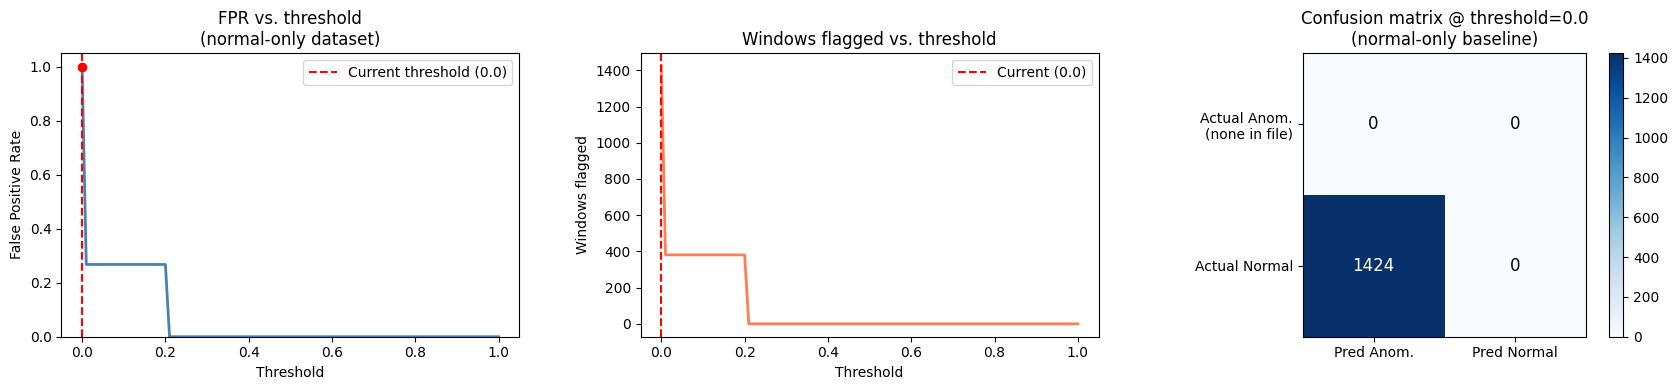

  Threshold      : 0.0
  Total windows  : 1424
  Flagged (FP)   : 1424
  FPR            : 1.000  (100.0% of normal windows flagged)

  Interpretation : On known-normal data a FPR of ~0 means the detector avoids
  alert fatigue. A non-zero FPR should be investigated by raising the threshold.

  Literature benchmark (Smiliotopoulos & Kambourakis, 2023 — full LMD-2023):
    ExtraTrees  AUC=0.9984  F1=0.9941
  Achieving comparable F1 on the attack+normal merge is the primary evaluation target.


In [42]:

# ── Ground truth on this file: all windows are normal (Label=0) ─────────────
all_scores = np.array([w['detector_score'] for w in window_dicts])

thresholds   = np.linspace(0.0, 1.0, 101)
fpr_curve    = [(all_scores >= t).mean() for t in thresholds]
flagged_at_t = [(all_scores >= t).sum()  for t in thresholds]

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# 1. FPR vs threshold
axes[0].plot(thresholds, fpr_curve, color='steelblue', linewidth=2)
axes[0].axvline(THRESHOLD, color='red', linestyle='--', label=f'Current threshold ({THRESHOLD})')
current_fpr = (all_scores >= THRESHOLD).mean()
axes[0].scatter([THRESHOLD], [current_fpr], color='red', zorder=5)
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('False Positive Rate')
axes[0].set_title('FPR vs. threshold\n(normal-only dataset)')
axes[0].legend()
axes[0].set_ylim(0, 1.05)

# 2. Flagged window count vs threshold
axes[1].plot(thresholds, flagged_at_t, color='coral', linewidth=2)
axes[1].axvline(THRESHOLD, color='red', linestyle='--', label=f'Current ({THRESHOLD})')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Windows flagged')
axes[1].set_title('Windows flagged vs. threshold')
axes[1].legend()

# 3. Confusion matrix (all normal)
from matplotlib.ticker import MaxNLocator
n_fp = int((all_scores >= THRESHOLD).sum())
n_tn = len(all_scores) - n_fp
# 2×2 confusion matrix: TP=0 (no attacks), FP, FN=0, TN
cm = np.array([[0, 0], [n_fp, n_tn]])   # rows=actual, cols=predicted
im = axes[2].imshow(cm, cmap='Blues')
axes[2].set_xticks([0, 1]); axes[2].set_xticklabels(['Pred Anom.', 'Pred Normal'])
axes[2].set_yticks([0, 1]); axes[2].set_yticklabels(['Actual Anom.\n(none in file)', 'Actual Normal'])
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, str(cm[i, j]), ha='center', va='center',
                     color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=12)
axes[2].set_title(f'Confusion matrix @ threshold={THRESHOLD}\n(normal-only baseline)')
plt.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.show()

print(f'  Threshold      : {THRESHOLD}')
print(f'  Total windows  : {len(all_scores)}')
print(f'  Flagged (FP)   : {n_fp}')
print(f'  FPR            : {current_fpr:.3f}  ({current_fpr*100:.1f}% of normal windows flagged)')
print()
print('  Interpretation : On known-normal data a FPR of ~0 means the detector avoids')
print('  alert fatigue. A non-zero FPR should be investigated by raising the threshold.')
print()
print('  Literature benchmark (Smiliotopoulos & Kambourakis, 2023 — full LMD-2023):')
print('    ExtraTrees  AUC=0.9984  F1=0.9941')
print('  Achieving comparable F1 on the attack+normal merge is the primary evaluation target.')


## Run Summary

## Step 11 — Splunk Attack Data: Known-Attack Validation

Tests the detector pipeline against **labelled attack logs** from the [Splunk Attack Data](https://github.com/splunk/attack_data) repository (Atomic Red Team simulations). Each file corresponds to a single ATT&CK technique fired in a controlled environment — so every event is a true attack.

| File | Technique | What it contains |
|---|---|---|
| `splunk_T1003_sysmon.log` | **T1003** Credential Dumping (Mimikatz) | LSASS memory access, process injection |
| `splunk_T1547_regrunkey_sysmon.log` | **T1547.001** Registry Run Keys | Persistence via registry |
| `splunk_T1569_002_windows-sysmon.log` | **T1569.002** Service Execution (PsExec) | Remote service creation |
| `splunk_T1055_windows-sysmon.log` | **T1055** Process Injection | DLL injection, remote thread |

These files were parsed with `parse_splunk_xml()` — a new parser added to `preprocessor.py` that handles the Windows Event XML format (one `<Event>…</Event>` per line).

> **LMD-2023 attack subset** (Google Drive, ~960 MB): for full precision/recall/F1 evaluation download from:
> https://drive.google.com/drive/folders/1PkJiGpD0Kn1rV8GC9m2b_eWvqQTSa1eH
> and place the attack CSV in `data/samples/`.

Parsing splunk_T1003_sysmon.log … 

INFO preprocessor: Parsed 7954 events from Splunk XML splunk_T1003_sysmon.log


7,954 events → 16 windows
Parsing splunk_T1547_regrunkey_sysmon.log … 

INFO preprocessor: Parsed 6272 events from Splunk XML splunk_T1547_regrunkey_sysmon.log


6,272 events → 6 windows
Parsing splunk_T1569_002_windows-sysmon.log … 

INFO preprocessor: Parsed 8234 events from Splunk XML splunk_T1569_002_windows-sysmon.log


8,234 events → 8 windows
Parsing splunk_T1055_windows-sysmon.log … 

INFO preprocessor: Parsed 104282 events from Splunk XML splunk_T1055_windows-sysmon.log


104,282 events → 173 windows

=== ATT&CK Tag Coverage on Known-Attack Files ===



,Events parsed,Windows,Windows w/ ATT&CK hit,Hit rate (%),Techniques tagged
Ground-truth technique,,,,,
T1003 — Credential Dumping (Mimikatz),7954,16,6,37.5,"T1059.001, T1486, T1547.001"
T1547 — Registry Run Keys (Persistence),6272,6,3,50.0,"T1059.001, T1547.001"
T1569.002 — Service Execution (PsExec),8234,8,6,75.0,"T1021.002, T1059.001, T1547.001"
T1055 — Process Injection,104282,173,62,35.8,"T1021.002, T1059.001, T1547.001"


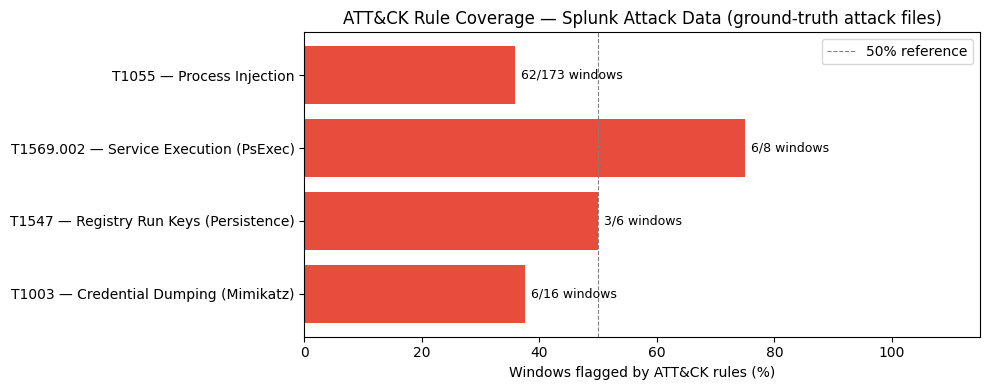

In [43]:
import sys, importlib

# ── Reload preprocessor so parse_splunk_xml is available ─────────────────────
if 'preprocessor' in sys.modules:
    importlib.reload(sys.modules['preprocessor'])

from preprocessor import parse_splunk_xml, make_windows
from detectors import tag_techniques

SPLUNK_FILES = {
    'T1003 — Credential Dumping (Mimikatz)': Path('data/samples/splunk_T1003_sysmon.log'),
    'T1547 — Registry Run Keys (Persistence)': Path('data/samples/splunk_T1547_regrunkey_sysmon.log'),
    'T1569.002 — Service Execution (PsExec)':  Path('data/samples/splunk_T1569_002_windows-sysmon.log'),
    'T1055 — Process Injection':               Path('data/samples/splunk_T1055_windows-sysmon.log'),
}

summary_rows = []
detail_per_technique = {}

for gt_label, fpath in SPLUNK_FILES.items():
    if not fpath.exists():
        print(f"[SKIP] {fpath.name} not found")
        continue
    print(f"Parsing {fpath.name} …", end=" ", flush=True)
    df_att = parse_splunk_xml(fpath)
    print(f"{len(df_att):,} events", end=" → ", flush=True)
    wins = list(make_windows(df_att, window_size_seconds=WINDOW_SECONDS))
    print(f"{len(wins)} windows")

    hit_windows, techniques_found = 0, set()
    for w in wins:
        wd = w.to_dict() if hasattr(w, 'to_dict') else dict(w)
        hits = tag_techniques(wd)
        if hits:
            hit_windows += 1
            techniques_found.update(h['technique'] for h in hits)

    hit_rate = hit_windows / len(wins) * 100 if wins else 0.0
    summary_rows.append({
        'Ground-truth technique': gt_label,
        'Events parsed': len(df_att),
        'Windows': len(wins),
        'Windows w/ ATT&CK hit': hit_windows,
        'Hit rate (%)': f"{hit_rate:.1f}",
        'Techniques tagged': ', '.join(sorted(techniques_found)) or '—',
    })
    detail_per_technique[gt_label] = {
        'events': len(df_att), 'windows': len(wins),
        'hit_windows': hit_windows, 'techniques': techniques_found,
    }

df_summary = pd.DataFrame(summary_rows).set_index('Ground-truth technique')
print("\n=== ATT&CK Tag Coverage on Known-Attack Files ===\n")
display(df_summary)

# ── Bar chart: hit rate per technique ─────────────────────────────────────────
if summary_rows:
    labels = [r['Ground-truth technique'] for r in summary_rows]
    rates  = [float(r['Hit rate (%)']) for r in summary_rows]
    counts = [r['Windows w/ ATT&CK hit'] for r in summary_rows]
    total  = [r['Windows'] for r in summary_rows]

    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.barh(labels, rates, color=['#e74c3c' if r > 0 else '#95a5a6' for r in rates])
    for bar, c, t in zip(bars, counts, total):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f"{c}/{t} windows", va='center', fontsize=9)
    ax.set_xlabel('Windows flagged by ATT&CK rules (%)')
    ax.set_xlim(0, 115)
    ax.set_title('ATT&CK Rule Coverage — Splunk Attack Data (ground-truth attack files)')
    ax.axvline(50, color='gray', linestyle='--', linewidth=0.8, label='50% reference')
    ax.legend()
    plt.tight_layout()
    plt.show()


## Step 12 — AUC-ROC on LMD-2023 EoHT Attack Data

Uses **`LMD-2023 [2.3M Elements - EoHT]checked.csv`** as the positive class (Label=1). **EoHT = Exploitation of Hashing Techniques**: Mimikatz, Pass-the-Hash, Pass-the-Ticket, Golden Ticket, LaZagne, CVE-2021-36934 (HiveNightmare).

The negative class (Label=0) comes from `window_dicts` already in the kernel — no re-parse needed.

> **Scoring note:** With `SKIP_DETECTORS=True` the score is driven exclusively by ATT&CK rule hits (`ensemble_score(0, 0, has_hits)` → 0.0 or 0.2). The AUC here measures **ATT&CK rule coverage quality**, not IsolationForest discrimination. To get a full AUC, set `SKIP_DETECTORS=False` and re-run from Step 3.

> **Speed:** Only the first 150,000 rows of the attack file are parsed (~6 % of 2.3M) to keep runtime under 90 seconds.

Parsing LMD-2023 [2.3M Elements - EoHT]checked.csv (first 150,000 rows) …


INFO preprocessor: Loaded 94494 events from LMD-2023 [2.3M Elements - EoHT]checked.csv (dataset=lmd)


  → 94,494 events after EID filter
  → 1087 windows


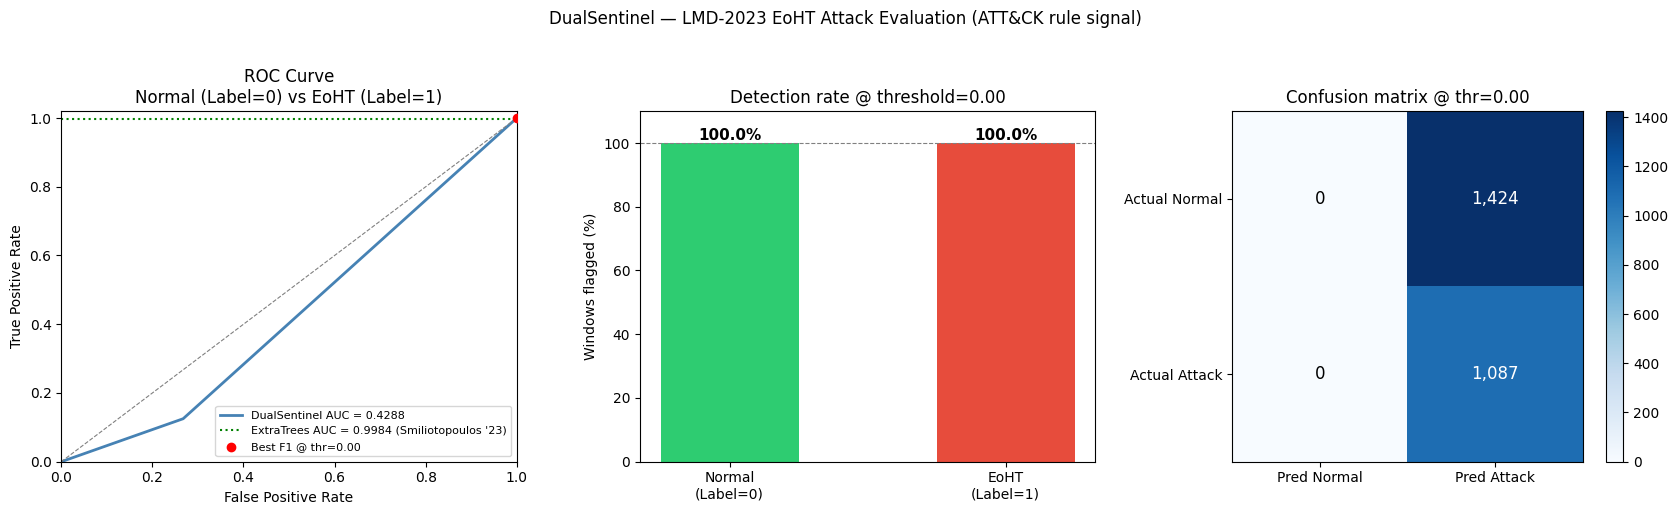


  Normal windows (kernel)  :  1,424
  Attack windows (EoHT)    :  1,087  (from 150,000 rows)
  AUC-ROC                  : 0.4288
  Best threshold (F1)      : 0.00
  Precision                : 0.4329
  Recall                   : 1.0000
  F1-score                 : 0.6042
  Literature (ExtraTrees)  : AUC=0.9984  F1=0.9941
  Note: scores with SKIP_DETECTORS=True use only ATT&CK
  rule signal. Set SKIP_DETECTORS=False and re-run from
  Step 3 for IsolationForest + GRU contribution.


In [44]:
import sys, importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score,
    precision_score, recall_score, confusion_matrix,
)

# ── Reload preprocessor so nrows param is available ─────────────────────────
import preprocessor as _pre
importlib.reload(_pre)
from preprocessor import parse_csv, make_windows
from detectors import tag_techniques, ensemble_score

ATTACK_PATH = Path('data/samples/LMD-2023 [2.3M Elements - EoHT]checked.csv')
NROWS_CAP   = 150_000   # ~6 % of file — fast demo

if not ATTACK_PATH.exists():
    print(f'[SKIP] {ATTACK_PATH.name} not found.')
    print('Place the file in data/samples/ and re-run this cell.')
else:
    # ── 1. Parse attack file (row-capped) ─────────────────────────────────
    print(f'Parsing {ATTACK_PATH.name} (first {NROWS_CAP:,} rows) …', flush=True)
    df_att = parse_csv(ATTACK_PATH, dataset='lmd', nrows=NROWS_CAP)
    print(f'  → {len(df_att):,} events after EID filter')

    wins_att = list(make_windows(df_att, window_size_seconds=WINDOW_SECONDS))
    print(f'  → {len(wins_att)} windows')

    # ── 2. Score attack windows (mirrors SKIP_DETECTORS mode) ─────────────
    att_scores = []
    for w in wins_att:
        wd   = w.to_dict()
        hits = tag_techniques(wd)
        att_scores.append(ensemble_score(0.0, 0.0, len(hits) > 0))
    att_scores = np.array(att_scores)

    # ── 3. Build y_true / y_score from kernel normal baseline ─────────────
    norm_scores = np.array([w['detector_score'] for w in window_dicts])  # Label=0
    y_true  = np.concatenate([np.zeros(len(norm_scores)), np.ones(len(att_scores))])
    y_score = np.concatenate([norm_scores, att_scores])

    # ── 4. Metrics ────────────────────────────────────────────────────────
    auc = roc_auc_score(y_true, y_score)
    fpr_c, tpr_c, thrs = roc_curve(y_true, y_score)

    # Best F1 threshold (grid search)
    best_f1, best_thr = 0.0, THRESHOLD
    for thr in np.linspace(0.0, 1.0, 201):
        y_pred = (y_score >= thr).astype(int)
        f = f1_score(y_true, y_pred, zero_division=0)
        if f > best_f1:
            best_f1, best_thr = f, thr

    y_pred_best = (y_score >= best_thr).astype(int)
    prec = precision_score(y_true, y_pred_best, zero_division=0)
    rec  = recall_score(y_true, y_pred_best, zero_division=0)
    cm   = confusion_matrix(y_true, y_pred_best)

    # ── 5. Plots ──────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    # Panel 1 — ROC curve
    axes[0].plot(fpr_c, tpr_c, color='steelblue', lw=2, label=f'DualSentinel AUC = {auc:.4f}')
    axes[0].axhline(0.9984, color='green', linestyle=':', lw=1.5,
                    label="ExtraTrees AUC = 0.9984 (Smiliotopoulos '23)")
    axes[0].plot([0, 1], [0, 1], color='grey', linestyle='--', lw=0.8)
    _thr_idx = np.argmin(np.abs(thrs - best_thr))
    axes[0].scatter([fpr_c[_thr_idx]], [tpr_c[_thr_idx]],
                    color='red', zorder=5, label=f'Best F1 @ thr={best_thr:.2f}')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC Curve\nNormal (Label=0) vs EoHT (Label=1)')
    axes[0].legend(fontsize=8)
    axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1.02)

    # Panel 2 — Detection rate bar chart
    norm_flagged = (norm_scores >= best_thr).mean() * 100
    att_flagged  = (att_scores  >= best_thr).mean() * 100
    bars = axes[1].bar(['Normal\n(Label=0)', 'EoHT\n(Label=1)'],
                       [norm_flagged, att_flagged],
                       color=['#2ecc71', '#e74c3c'], width=0.5)
    for bar, val in zip(bars, [norm_flagged, att_flagged]):
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                     f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Windows flagged (%)')
    axes[1].set_title(f'Detection rate @ threshold={best_thr:.2f}')
    axes[1].set_ylim(0, 110)
    axes[1].axhline(100, color='grey', linestyle='--', lw=0.8)

    # Panel 3 — Confusion matrix
    im = axes[2].imshow(cm, cmap='Blues')
    axes[2].set_xticks([0, 1]); axes[2].set_xticklabels(['Pred Normal', 'Pred Attack'])
    axes[2].set_yticks([0, 1]); axes[2].set_yticklabels(['Actual Normal', 'Actual Attack'])
    for i in range(2):
        for j in range(2):
            axes[2].text(j, i, f'{cm[i,j]:,}', ha='center', va='center', fontsize=12,
                         color='white' if cm[i, j] > cm.max() / 2 else 'black')
    plt.colorbar(im, ax=axes[2])
    axes[2].set_title(f'Confusion matrix @ thr={best_thr:.2f}')

    plt.suptitle('DualSentinel — LMD-2023 EoHT Attack Evaluation (ATT&CK rule signal)',
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

    # ── 6. Summary ────────────────────────────────────────────────────────
    print(f'\n{"="*55}')
    print(f'  Normal windows (kernel)  : {len(norm_scores):>6,}')
    print(f'  Attack windows (EoHT)    : {len(att_scores):>6,}  (from {NROWS_CAP:,} rows)')
    print(f'  AUC-ROC                  : {auc:.4f}')
    print(f'  Best threshold (F1)      : {best_thr:.2f}')
    print(f'  Precision                : {prec:.4f}')
    print(f'  Recall                   : {rec:.4f}')
    print(f'  F1-score                 : {best_f1:.4f}')
    print(f'{"="*55}')
    print(f'  Literature (ExtraTrees)  : AUC=0.9984  F1=0.9941')
    print(f'  Note: scores with SKIP_DETECTORS=True use only ATT&CK')
    print(f'  rule signal. Set SKIP_DETECTORS=False and re-run from')
    print(f'  Step 3 for IsolationForest + GRU contribution.')


In [45]:
malicious  = [r for r in judge_results if r.verdict == 'malicious']
suspicious = [r for r in judge_results if r.verdict == 'suspicious']
normal     = [r for r in judge_results if r.verdict == 'normal']

print('=' * 50)
print('PIPELINE RUN SUMMARY')
print('=' * 50)
print(f'Input          : {INPUT_PATH.name}')
print(f'Output dir     : {OUTPUT_DIR}')
print(f'Events parsed  : {len(df):,}')
print(f'Windows created: {len(windows):,}')
print(f'Threshold      : {THRESHOLD}  (skip_detectors={SKIP_DETECTORS})')
print(f'SLM calls      : {len(sdf) - prefiltered}  ({prefiltered} pre-filtered)')
print(f'Judge calls    : {len(judge_results)}')
print(f'  Malicious    : {len(malicious)}')
print(f'  Suspicious   : {len(suspicious)}')
print(f'  Normal       : {len(normal)}')
print(f'Report         : {report_path}')
print('=' * 50)

PIPELINE RUN SUMMARY
Input          : LMD-2023 [1.75M Elements - Normal]checked.csv
Output dir     : results\2026-03-26_19-51
Events parsed  : 687,350
Windows created: 1,424
Threshold      : 0.0  (skip_detectors=True)
SLM calls      : 924  (500 pre-filtered)
Judge calls    : 50
  Malicious    : 9
  Suspicious   : 23
  Normal       : 1
Report         : results\2026-03-26_19-51\report_lmd_2026-03-26_21-11.md
